# Superstore Sales Profitability Analysis

This notebook analyzes the Sample Superstore dataset using Exploratory Data Analysis (EDA), K-Means Clustering, and Linear Regression to identify profitability drivers and generate business insights.

### Import Libraries
This section imports the required Python libraries for data manipulation, visualization, machine learning, and model evaluation.

In [ ]:
# Libraries for work
import os
import warnings

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)
warnings.filterwarnings("ignore", category=UserWarning)

# Direct fix: prevent joblib from trying to detect physical CPU cores using a subprocess on Windows.
import joblib.externals.loky.backend.context as _loky_context
_loky_context._count_physical_cores = lambda: (os.cpu_count() or 4, None)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'


### Load Dataset
Load the Superstore dataset into a pandas DataFrame for analysis.

In [ ]:
df = pd.read_csv('SampleSuperstore.csv', encoding='utf-8-sig')

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


### Data Exploration
Inspect the dataset structure, missing values, duplicates, and summary statistics to understand data quality.

In [4]:
print("=== Information ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

=== Information ===
Rows: 9,994
Columns: 13

Data types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Null values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicates: 17


### Exploratory Data Analysis (EDA)
Visualize sales, profits, discounts, and other business metrics to discover trends and patterns.

### Descriptive Statistics
Summary stats for the core numeric variables. Two things stand out right away: **Profit** has a huge spread (from -$6,600 to $8,399) and its mean ($28.66) sits far above its median ($8.67) — a strong hint of outliers and right-skew we'll see again in the histogram below.

In [5]:
print("=== descriptive statistics ===")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

=== descriptive statistics ===


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


### Sales & Profit Distributions
Both variables are right-skewed: most transactions are small, with a long tail of high-value orders pulling the average up.

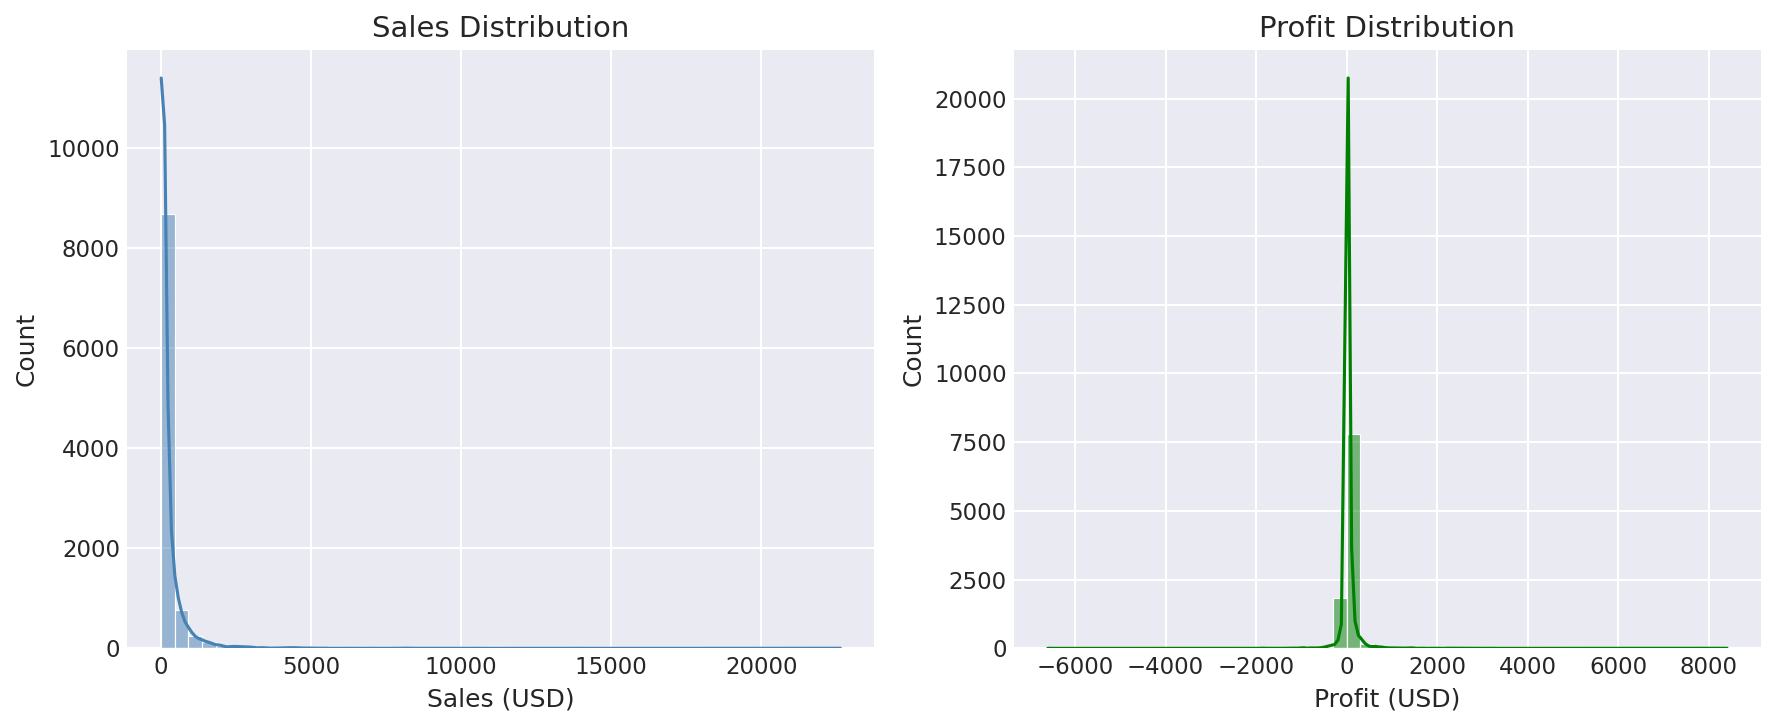

In [6]:
fig, axes = plt.subplots(1, 2)

sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales (USD)')

sns.histplot(df['Profit'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit (USD)')

plt.tight_layout()
plt.show()

### Profit by Category
Total profit aggregated at the broadest level — Category — to get a first read on which product lines are worth the most before drilling into sub-categories.

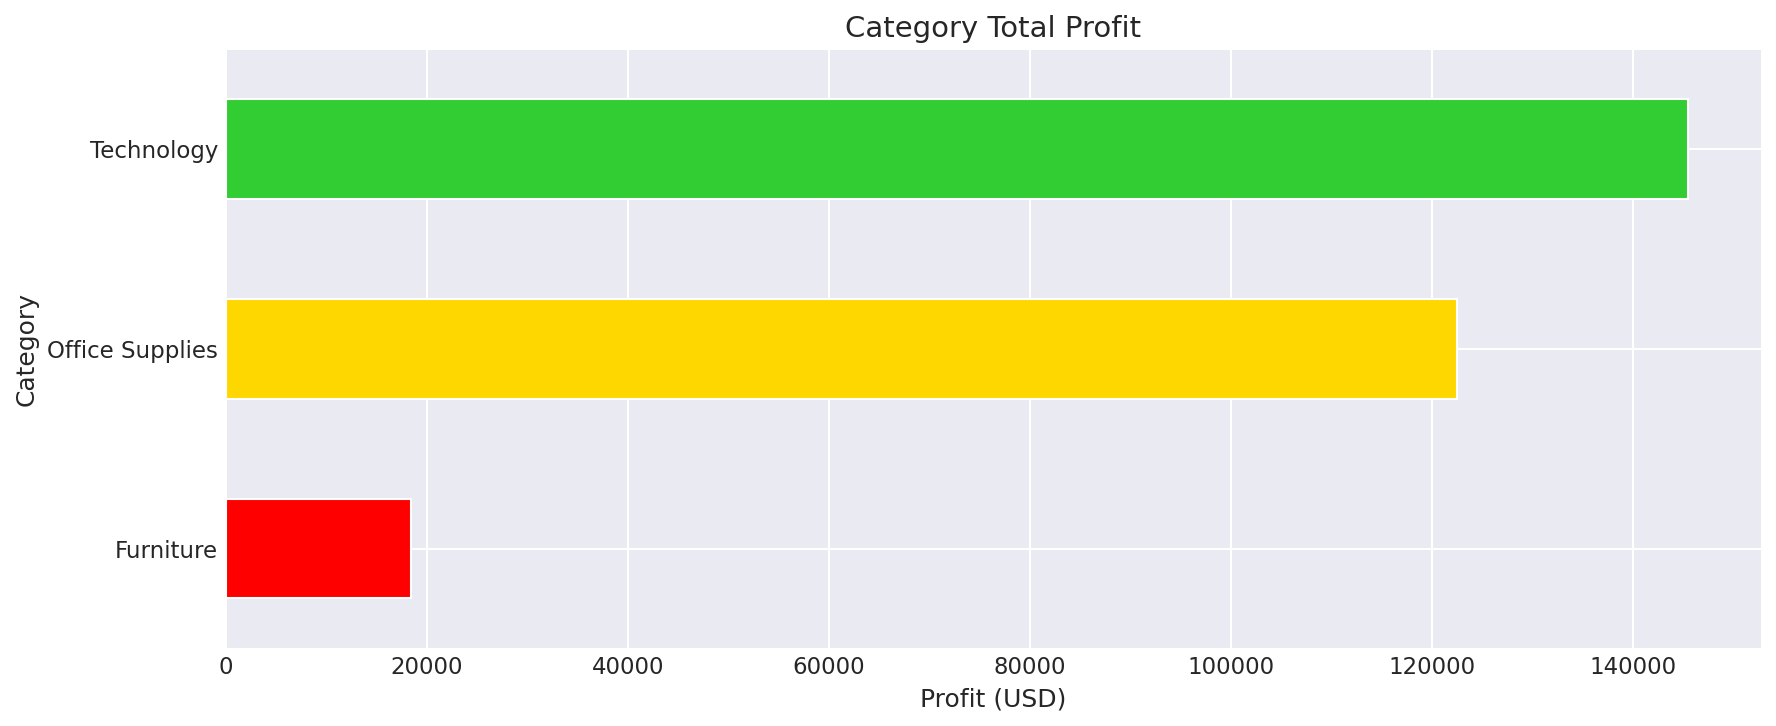

In [7]:
profit_cat = df.groupby('Category')['Profit'].sum().sort_values()

profit_cat.plot(kind='barh', color=['red','gold','limegreen'])
plt.title('Category Total Profit')
plt.xlabel('Profit (USD)')
plt.tight_layout()
plt.show()

### Discount vs. Profit
Do higher discounts eat into profit? Plotting every transaction, colored by Category, to check for a visual pattern before confirming it numerically in the correlation matrix.

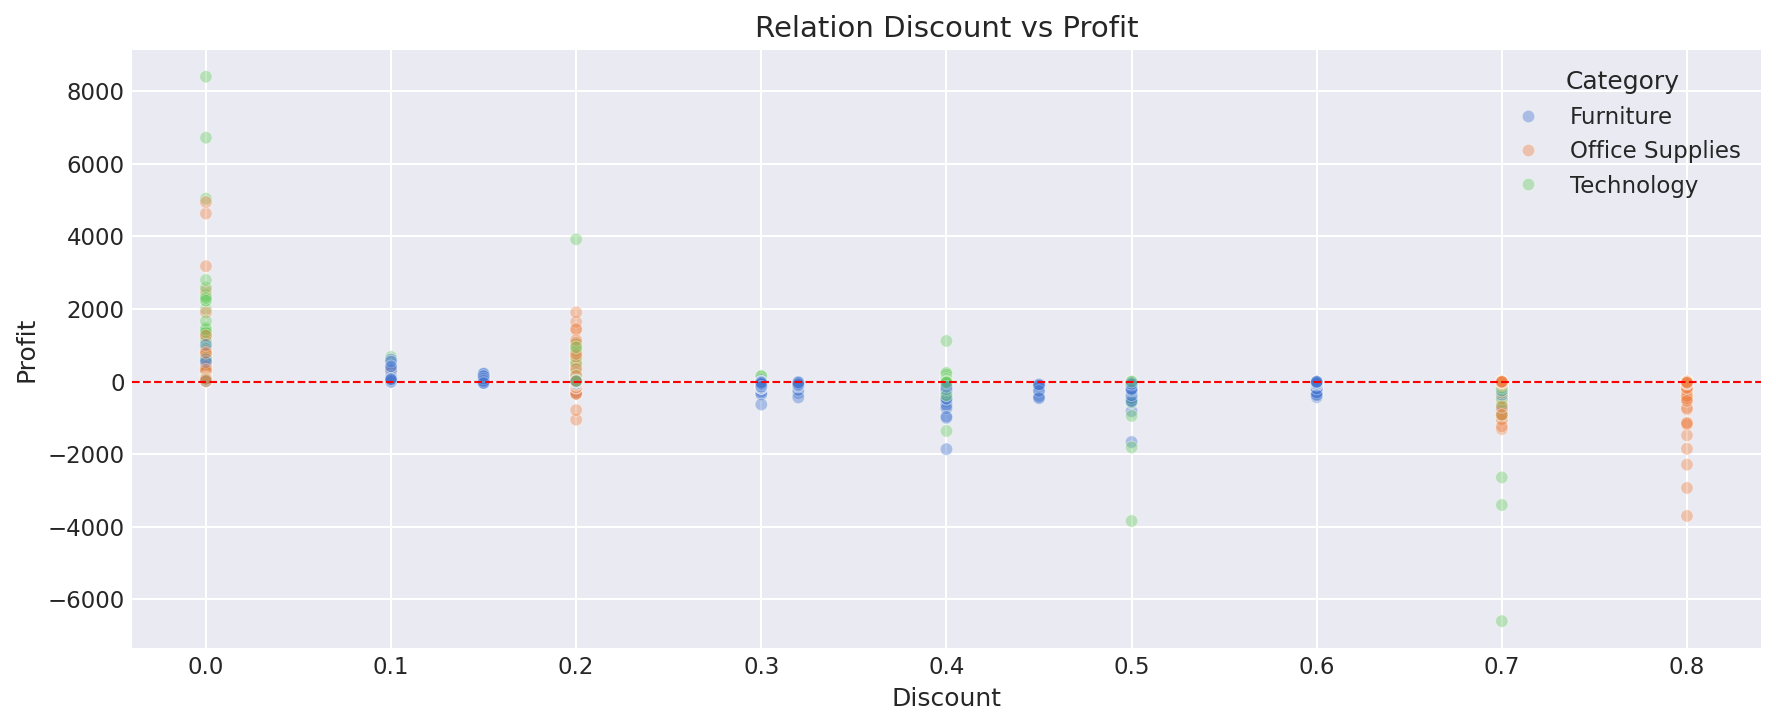

In [8]:
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, hue='Category')
plt.title('Relation Discount vs Profit')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### Profit by Region and Segment
Cross-tabulating Profit by Region and Segment to spot where profit concentrates — and where it doesn't — across the business.

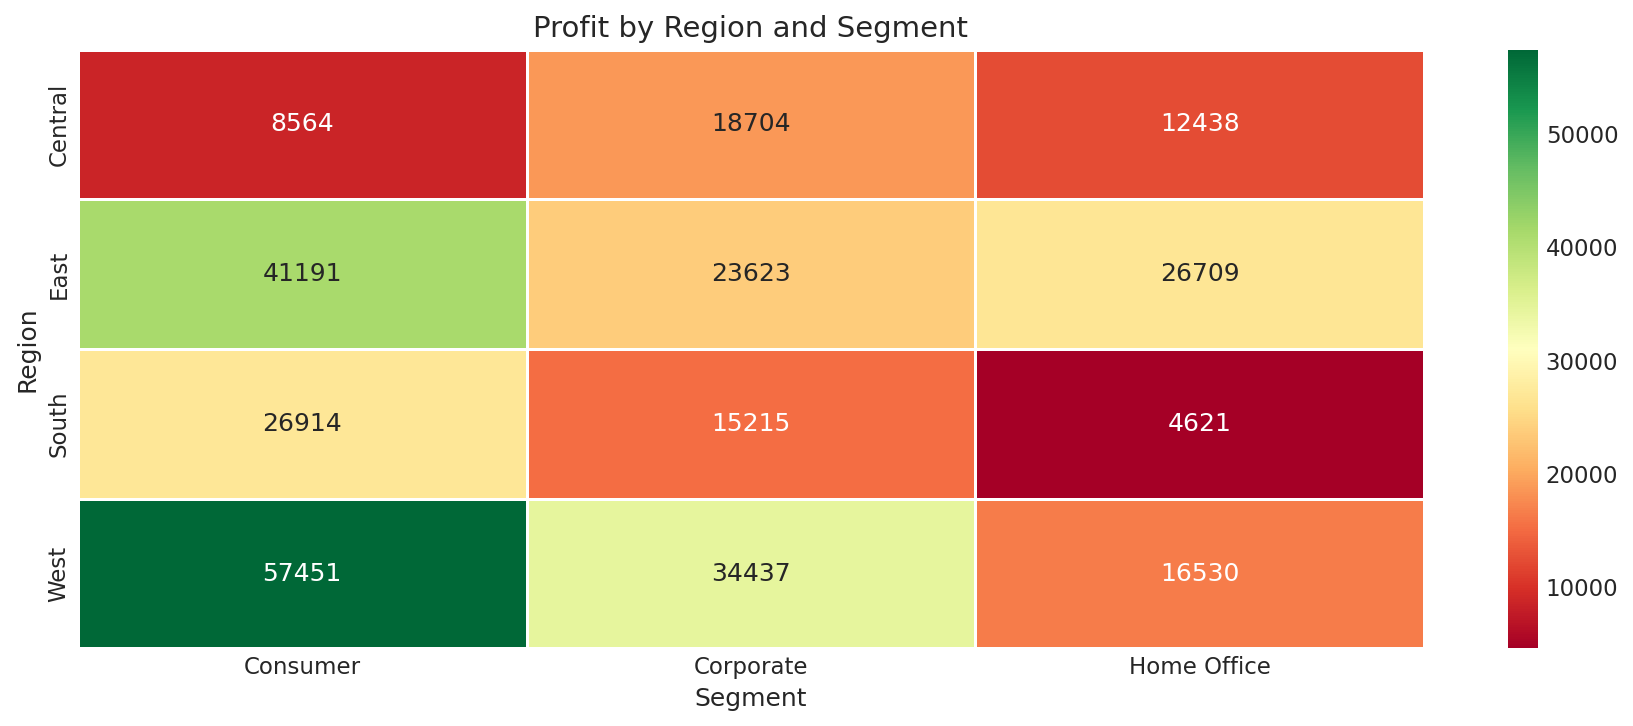

In [9]:
pivot = df.pivot_table(values='Profit', index='Region', columns='Segment', aggfunc='sum').round(0)

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5)
plt.title('Profit by Region and Segment')
plt.tight_layout()
plt.show()

### Profit by Sub-Category
The same total-profit view as above, but at the Sub-Category level — granular enough to name exactly which product lines are losing money (flagged in red).

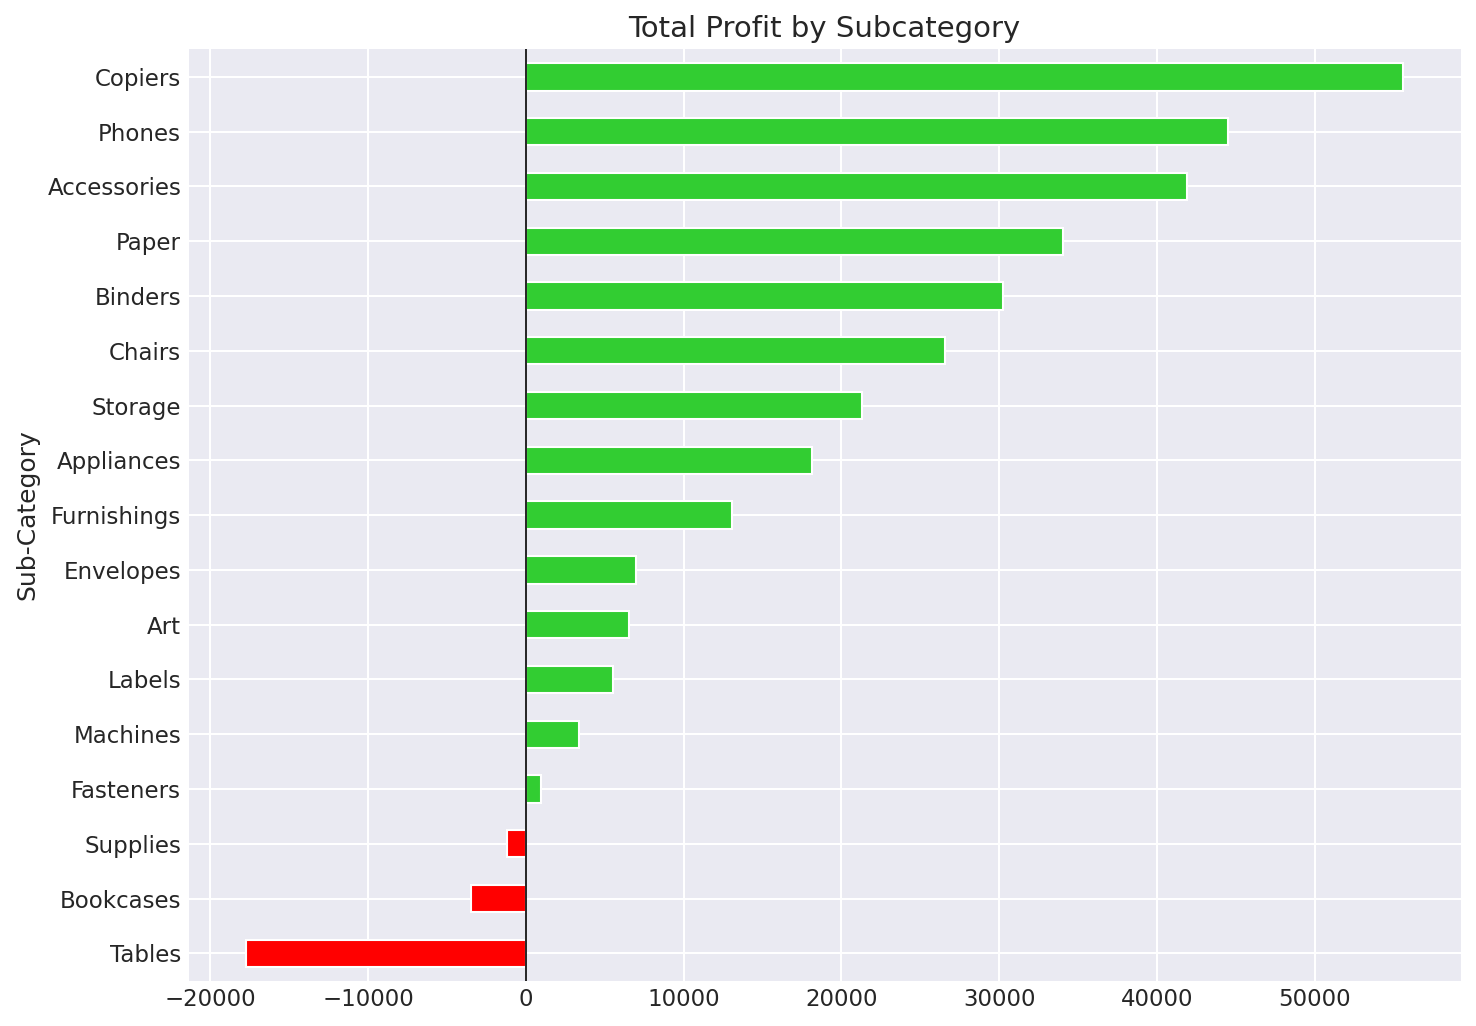

In [10]:


subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['red' if x < 0 else 'limegreen' for x in subcat_profit]
subcat_profit.plot(kind='barh', color=colors, figsize=(10, 7))
plt.title('Total Profit by Subcategory')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Correlation Matrix
Checking linear relationships between Sales, Quantity, Discount, and Profit — this sets expectations for the Linear Regression model later on.

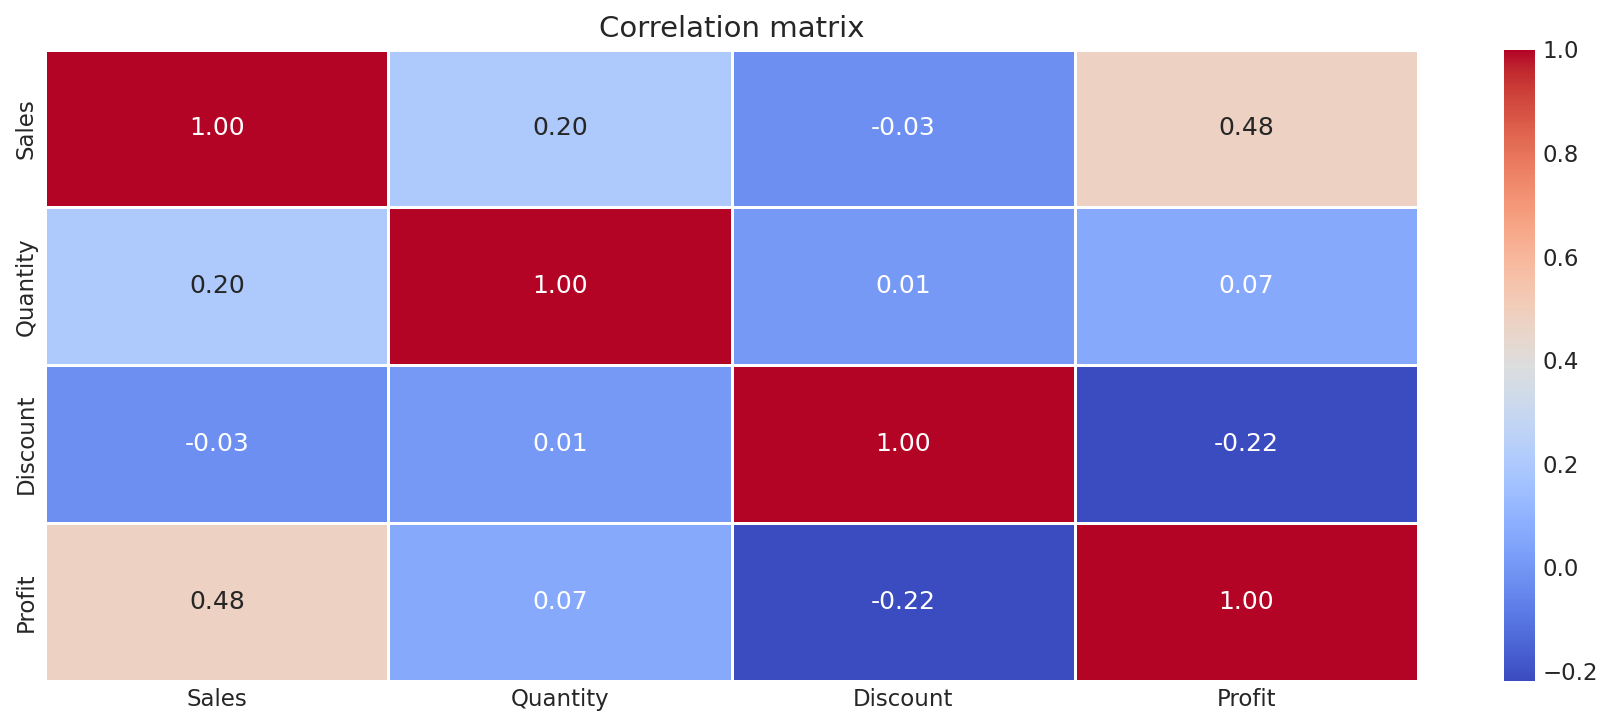

In [11]:
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

### Removing Duplicates
Before moving into clustering, we drop duplicate rows so repeated transactions don't distort the cluster centroids.

In [12]:
df = df.drop_duplicates()
print(f" Duplicates removed. Remaining rows: {df.shape[0]:,}")

 Duplicates removed. Remaining rows: 9,977


### Customer Segmentation (K-Means)
Apply K-Means clustering to identify groups of customers or transactions with similar purchasing behavior.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print(" Clustering libraries loaded")

 Clustering libraries loaded


In [14]:
features = ['Sales', 'Quantity', 'Discount']  
X = df[features].copy()

X['Sales'] = np.log1p(X['Sales'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Finding the Optimal K
Before assigning clusters, we test K = 2 to 10 using two complementary methods: the **elbow method** (looks for the point where adding more clusters stops reducing inertia much) and the **silhouette score** (measures how well-separated the clusters are). We compare both plots to settle on a final K.

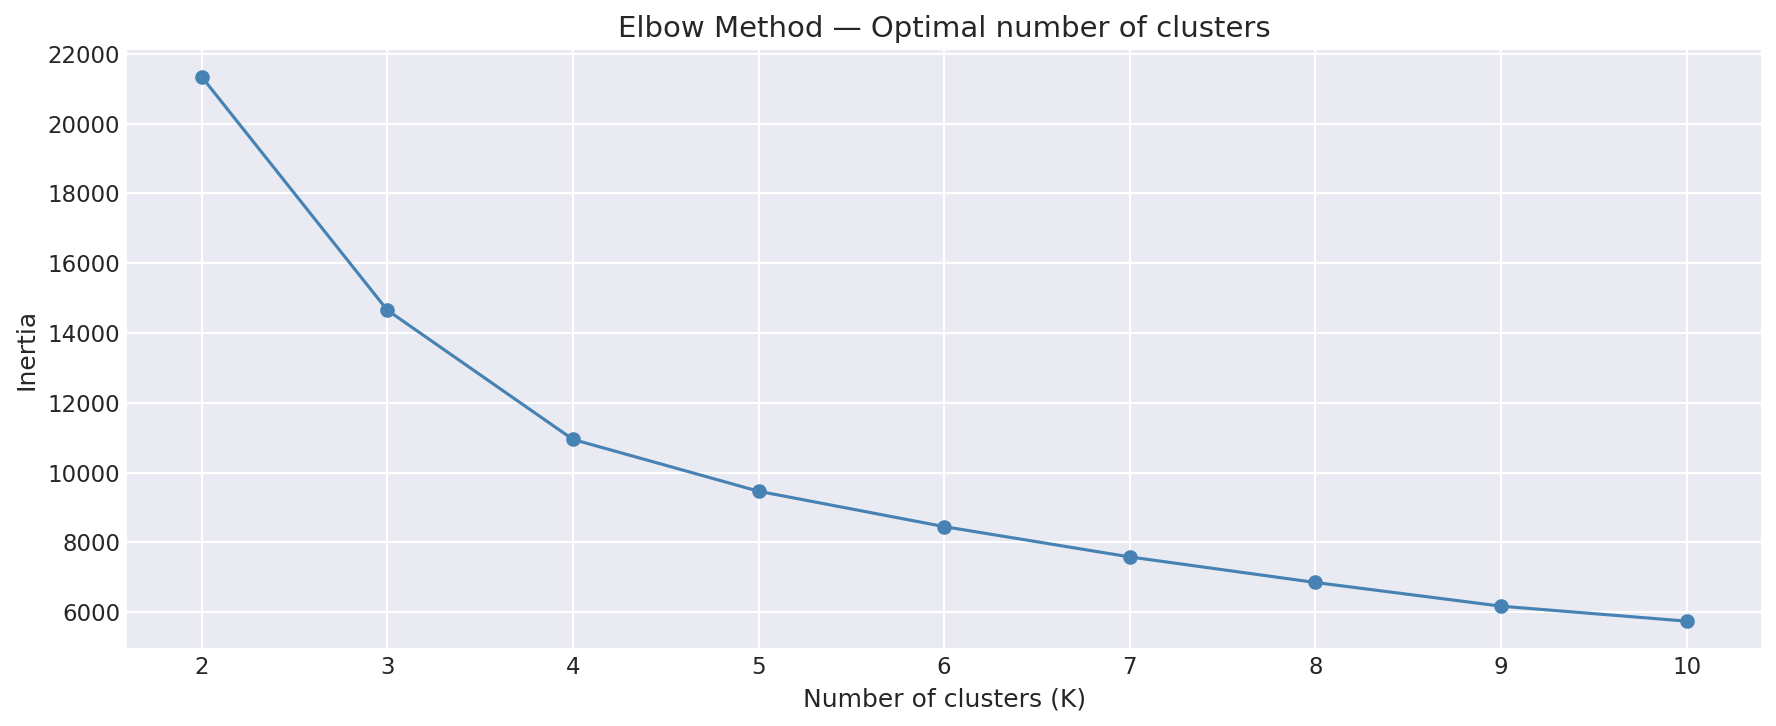

In [15]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal number of clusters')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

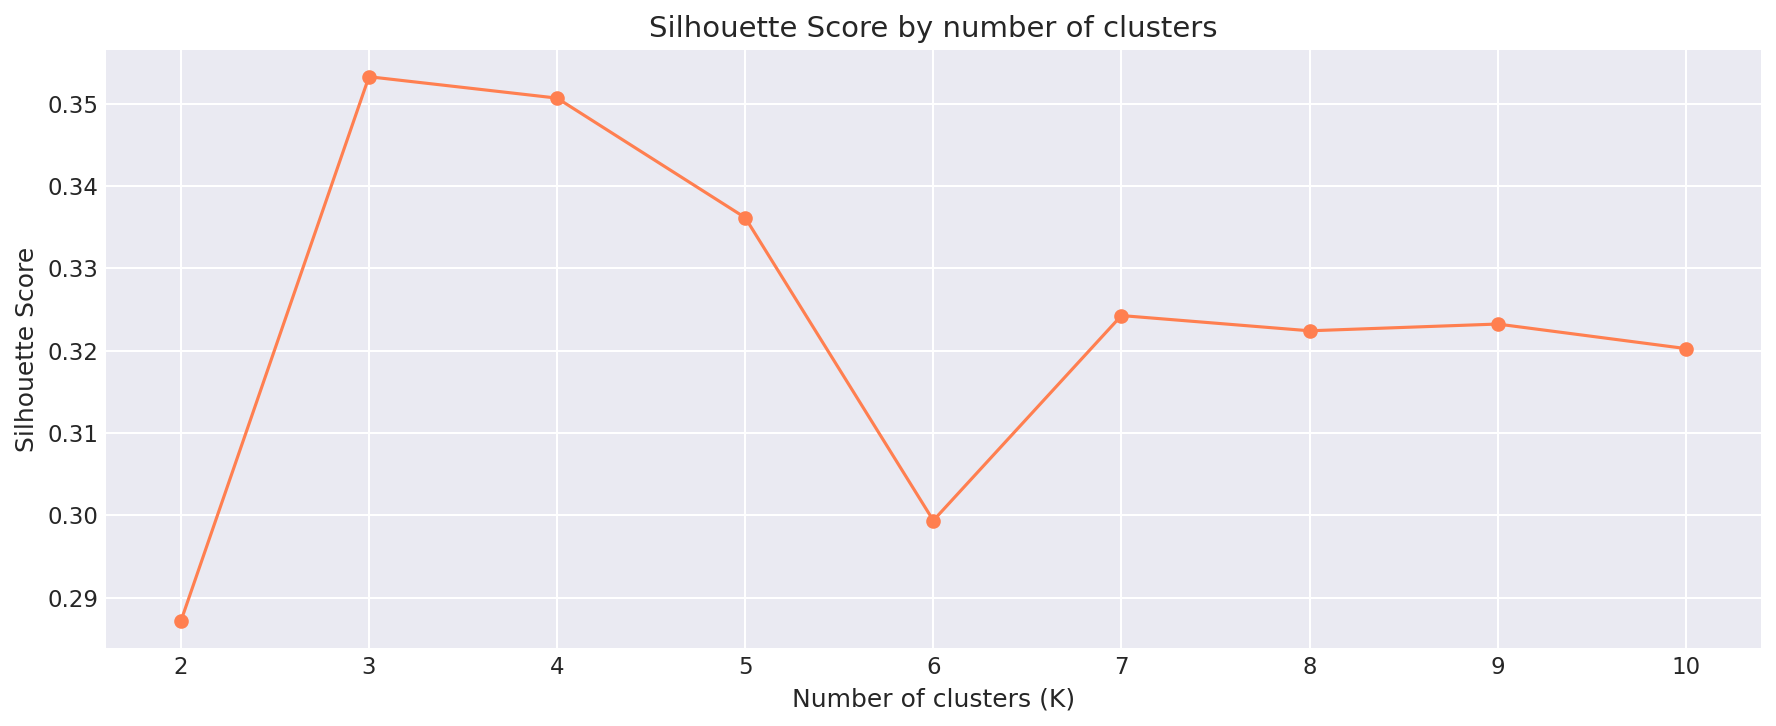

In [16]:
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, silhouettes, marker='o', color='coral')
plt.title('Silhouette Score by number of clusters')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Both the elbow curve and the silhouette score point to a comparable trade-off. Based on that comparison, we set **K = 4** for the final clustering.

In [17]:
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f" Clusters assigned with K={K_OPTIMAL}")
print(df['Cluster'].value_counts().sort_index())

 Clusters assigned with K=4
Cluster
0    3224
1    4242
2    1637
3     874
Name: count, dtype: int64


In [18]:
profile_with_profit = df.groupby('Cluster')[['Sales', 'Quantity', 'Discount', 'Profit']].mean().round(2)
print("=== AVERAGE PROFILE PER CLUSTER (incl. Profit for interpretation) ===")
print(profile_with_profit)

=== AVERAGE PROFILE PER CLUSTER (incl. Profit for interpretation) ===
          Sales  Quantity  Discount  Profit
Cluster                                    
0        437.26      3.26      0.12   66.58
1         25.11      2.71      0.09    7.20
2        439.86      7.61      0.10   67.47
3         68.55      3.83      0.71  -79.42


### Interpreting the Clusters
With K = 4, the average profile per cluster (Profit added afterward, for interpretation only — it was not used to train the clustering) reveals four distinct transaction profiles:
- **Cluster 0** (3,224 rows): mid-size orders, moderate discount — avg. sales ~$437, ~3 items/order, profit ~$67.
- **Cluster 1** (4,242 rows): small everyday orders — avg. sales ~$25, modest profit ~$7. The most common transaction type.
- **Cluster 2** (1,637 rows): similar order value to Cluster 0 but much higher quantity per order (~7.6 items) — bulk purchases, comparably profitable (~$67).
- **Cluster 3** (874 rows): heavily discounted orders (avg. discount 71%) that lose money on average — profit **-$79**.

Cluster 3 is the one to watch — it's where high discounts are eroding profitability, which we dig into next at the sub-category level.

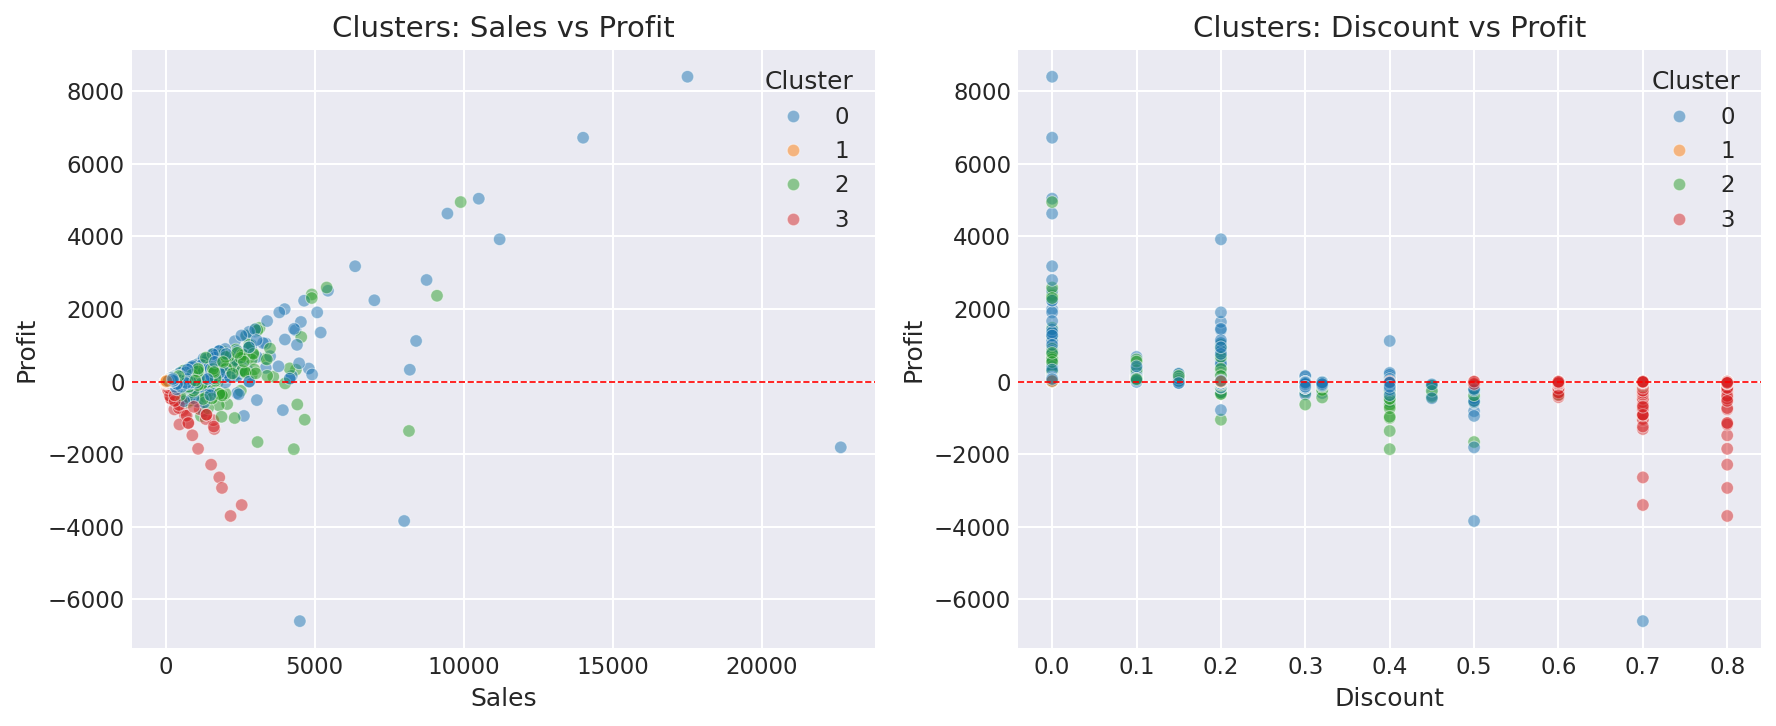

In [19]:
fig, axes = plt.subplots(1, 2)

# Sales vs Profit by cluster
sns.scatterplot(data=df, x='Sales', y='Profit',
                hue='Cluster', palette='tab10',
                alpha=0.5, ax=axes[0])
axes[0].set_title('Clusters: Sales vs Profit')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)

# Discount vs Profit by cluster
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Cluster', palette='tab10',
                alpha=0.5, ax=axes[1])
axes[1].set_title('Clusters: Discount vs Profit')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

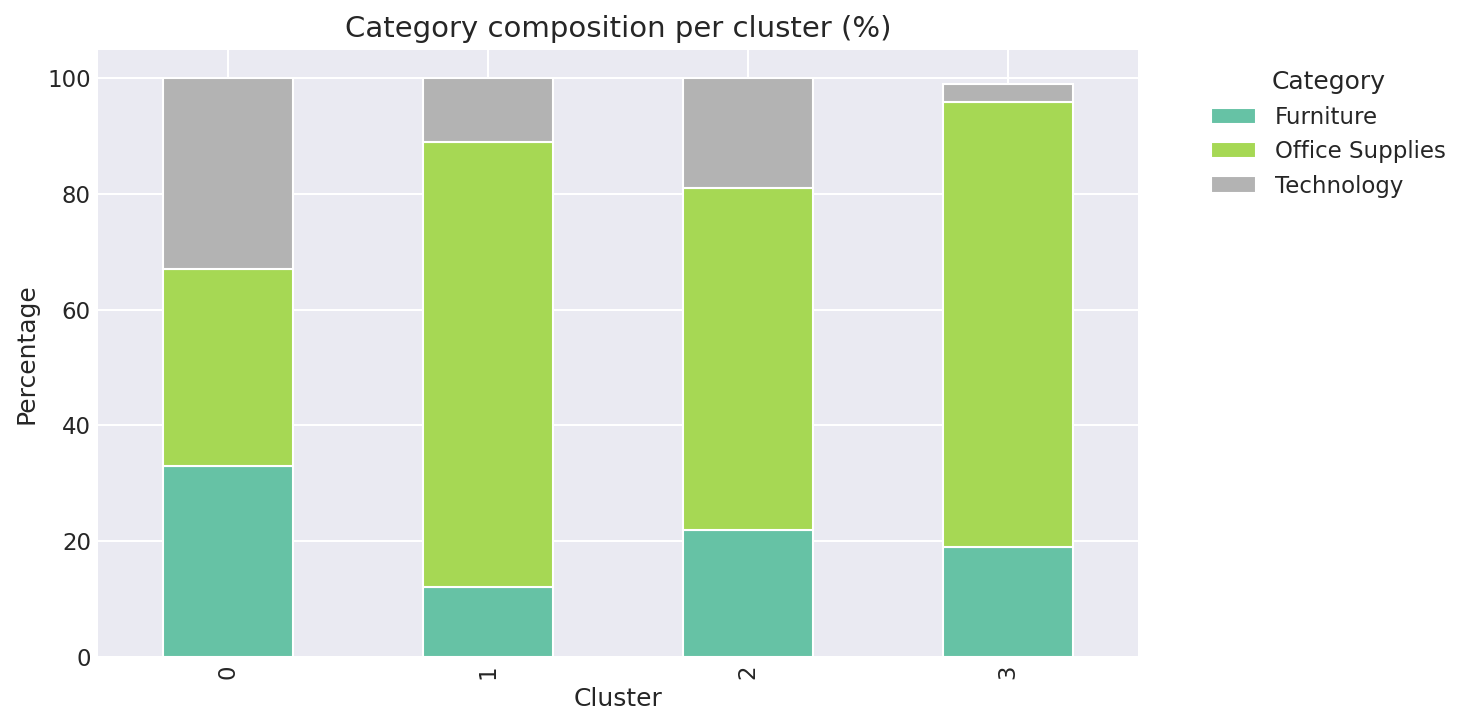

In [20]:
ct = pd.crosstab(df['Cluster'], df['Category'], normalize='index').round(2) * 100

ct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 5))
plt.title('Category composition per cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Which Sub-Categories Are Losing Money?
Zooming in from the cluster-level pattern to individual sub-categories, we flag which ones have negative total profit and check whether high discounts explain the loss.

In [21]:
# Sub-categories with negative total profit
subcat_analysis = df.groupby('Sub-Category').agg(
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Sales=('Sales', 'mean'),
    Transactions=('Profit', 'count')
).round(2).sort_values('Total_Profit')

# Flag losing sub-categories
subcat_analysis['Status'] = subcat_analysis['Total_Profit'].apply(
    lambda x: 'Loss' if x < 0 else 'Profit'
)

def color_status(val):
    color = 'red' if val == 'Loss' else 'green'
    return f'color: {color}; font-weight: bold'

print("=== SUB-CATEGORY PERFORMANCE ===")
display(subcat_analysis.style.map(color_status, subset=['Status']))

=== SUB-CATEGORY PERFORMANCE ===


,Total_Profit,Avg_Discount,Avg_Sales,Transactions,Status
Sub-Category,,,,,
Tables,-17725.480000,0.260000,648.790000,319,Loss
Bookcases,-3472.560000,0.210000,503.860000,228,Loss
Supplies,-1189.100000,0.080000,245.650000,190,Loss
Fasteners,949.520000,0.080000,13.940000,217,Profit
Machines,3384.760000,0.310000,1645.550000,115,Profit
Labels,5526.380000,0.070000,34.280000,363,Profit
Art,6524.610000,0.070000,34.100000,795,Profit
Envelopes,6964.180000,0.080000,64.870000,254,Profit
Furnishings,13052.720000,0.140000,95.900000,956,Profit


### Linear Regression
Train a Linear Regression model to predict **Profit** using **Sales**, **Quantity**, and **Discount**. This model was selected because Profit is a continuous numerical variable.

In [22]:
X_reg = pd.get_dummies(
    df[['Sales', 'Quantity', 'Discount', 'Category', 'Region']],
    columns=['Category', 'Region'],
    drop_first=True
)
y_reg = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print(" Model trained")
print(f"Intercept: {model.intercept_:.2f}")
print(f"\nCoefficients:")
for feat, coef in zip(X_reg.columns, model.coef_):
    print(f"  {feat}: {coef:.4f}")

 Model trained
Intercept: 7.66

Coefficients:
  Sales: 0.1851
  Quantity: -3.2485
  Discount: -233.0621
  Category_Office Supplies: 49.0373
  Category_Technology: 43.9985
  Region_East: -10.0486
  Region_South: -13.5303
  Region_West: -16.2470


### Discount Scenario Simulation
Using the Linear Regression model, we simulate what would happen to profit in the losing sub-categories (Tables, Bookcases, Supplies) if their discounts were reduced by 20%, 40%, or removed entirely. This turns the regression coefficients into a concrete, actionable business scenario.

In [23]:
losing_subcats = subcat_analysis[subcat_analysis['Total_Profit'] < 0].index.tolist()
df_loss = df[df['Sub-Category'].isin(losing_subcats)].copy()

scenarios = {
    'Current':       df_loss['Discount'],
    'Discount -20%': (df_loss['Discount'] * 0.8).clip(0, 0.8),
    'Discount -40%': (df_loss['Discount'] * 0.6).clip(0, 0.8),
    'No Discount':   pd.Series(0, index=df_loss.index)
}

results = {}
for scenario, discount_values in scenarios.items():
    
    X_sim = pd.get_dummies(
        df_loss[['Sales', 'Quantity', 'Discount', 'Category', 'Region']],
        columns=['Category', 'Region'],
        drop_first=True
    )
    X_sim['Discount'] = discount_values
    X_sim = X_sim.reindex(columns=X_reg.columns, fill_value=0)  
    predicted_profit = model.predict(X_sim)
    results[scenario] = predicted_profit.sum().round(0)

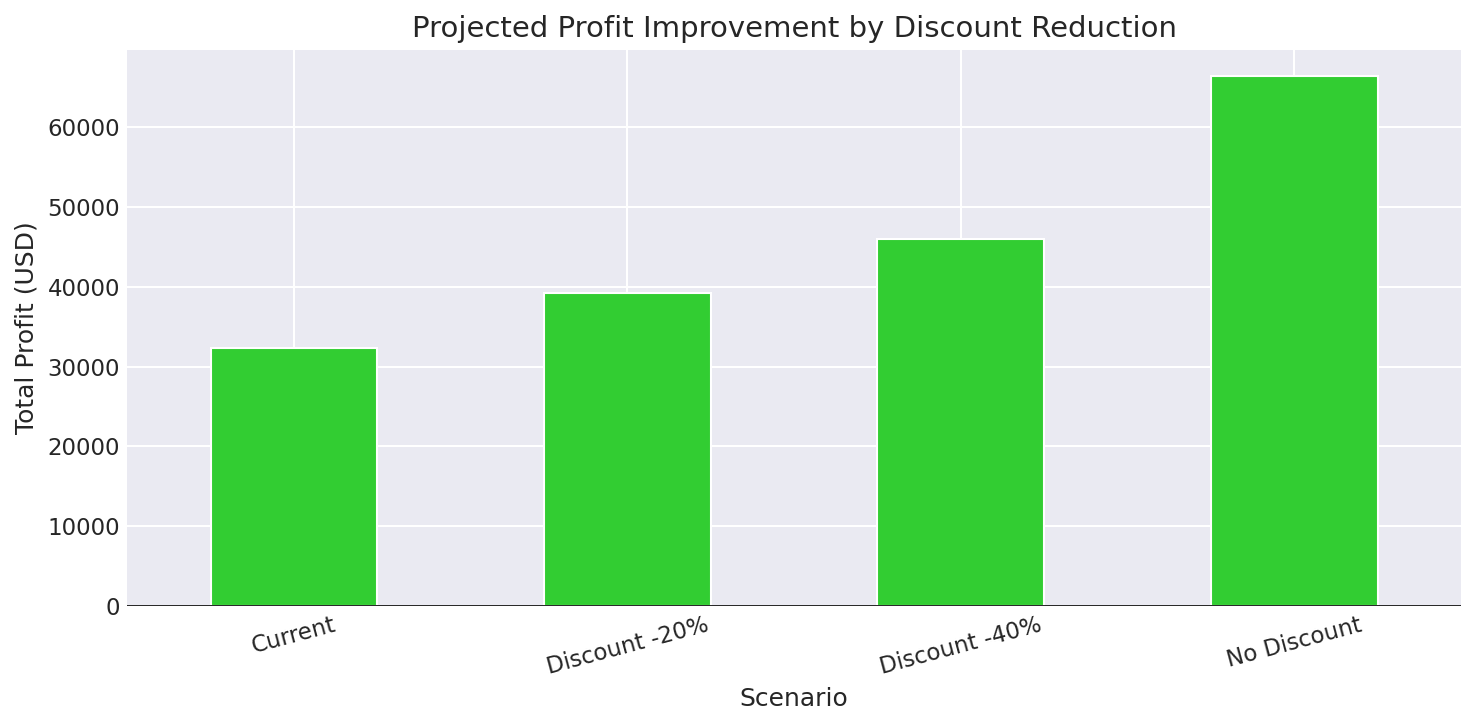

In [24]:
scenarios_df = pd.DataFrame({
    'Scenario': list(results.keys()),
    'Total Profit': list(results.values())
})

colors = ['red' if v < 0 else 'limegreen' for v in scenarios_df['Total Profit']]
scenarios_df.plot(kind='bar', x='Scenario', y='Total Profit',
                  color=colors, legend=False, figsize=(10, 5))

plt.title('Projected Profit Improvement by Discount Reduction')
plt.xlabel('Scenario')
plt.ylabel('Total Profit (USD)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Model Evaluation
Evaluate model performance using R², MAE, and RMSE to measure prediction accuracy.

In [25]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== MODEL EVALUATION ===")
print(f"R² Score:              {r2:.4f}")
print(f"Mean Absolute Error:   ${mae:.2f}")
print(f"Intercept:             {model.intercept_:.2f}")

=== MODEL EVALUATION ===
R² Score:              0.1798
Mean Absolute Error:   $59.45
Intercept:             7.66


### Predicted vs. Actual
Each point is one test-set transaction: the x-axis is the real profit, the y-axis is what the model predicted. Points close to the diagonal line are accurate predictions.

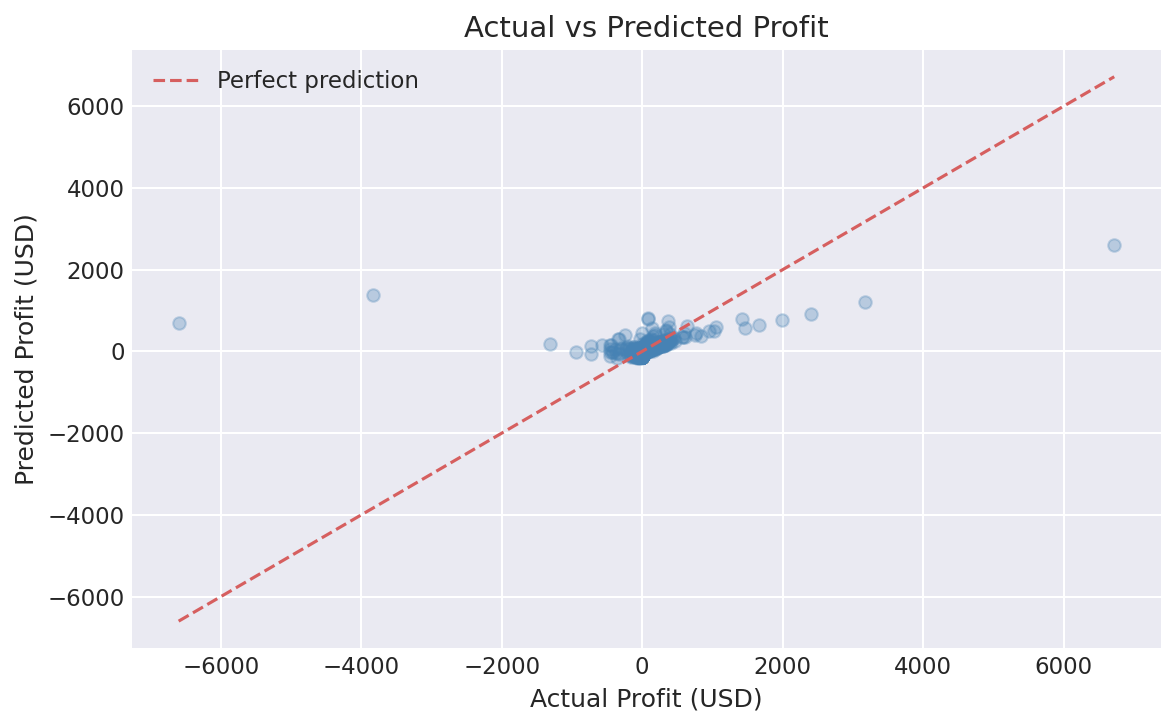

In [26]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.title('Actual vs Predicted Profit')
plt.xlabel('Actual Profit (USD)')
plt.ylabel('Predicted Profit (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### Residual Analysis
Residuals = actual profit − predicted profit. A distribution centered around zero with no strong skew suggests the model isn't systematically over- or under-predicting.

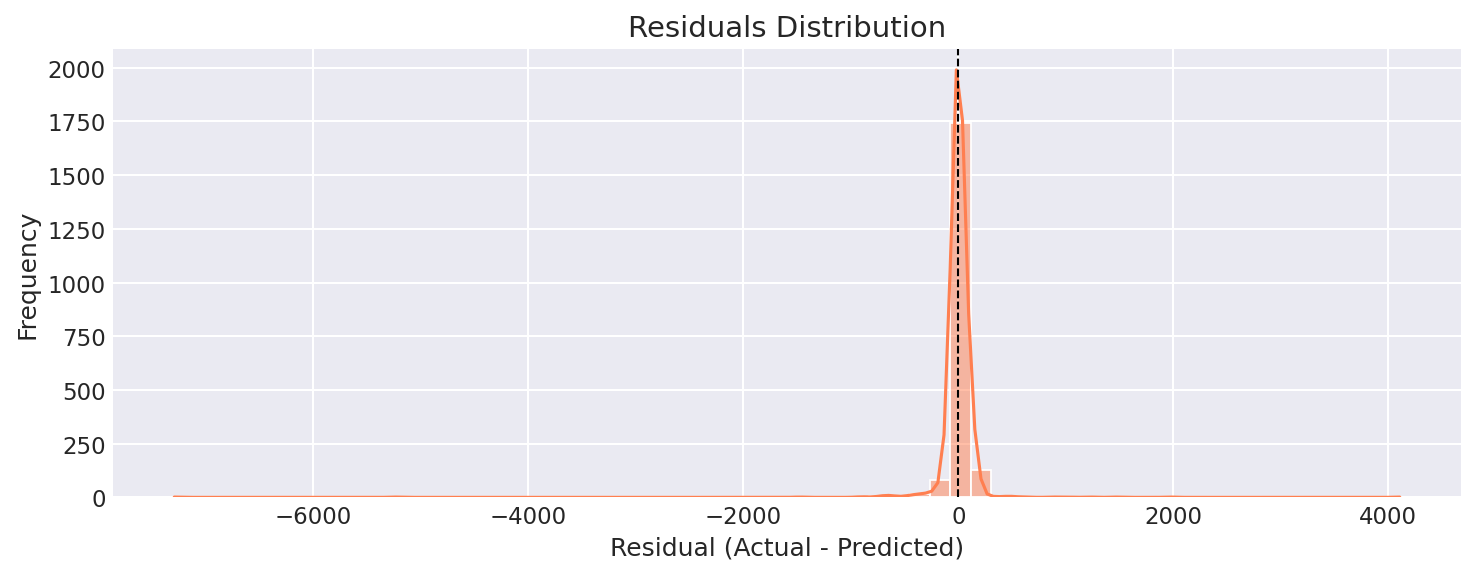

Mean residual: -1.36
Std residual:  250.06


In [27]:
# Residuals = difference between actual and predicted
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=60, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual:  {residuals.std():.2f}")

### Feature Coefficients
How much each feature moves predicted profit, holding the others constant — this is the basis for the business interpretation below.

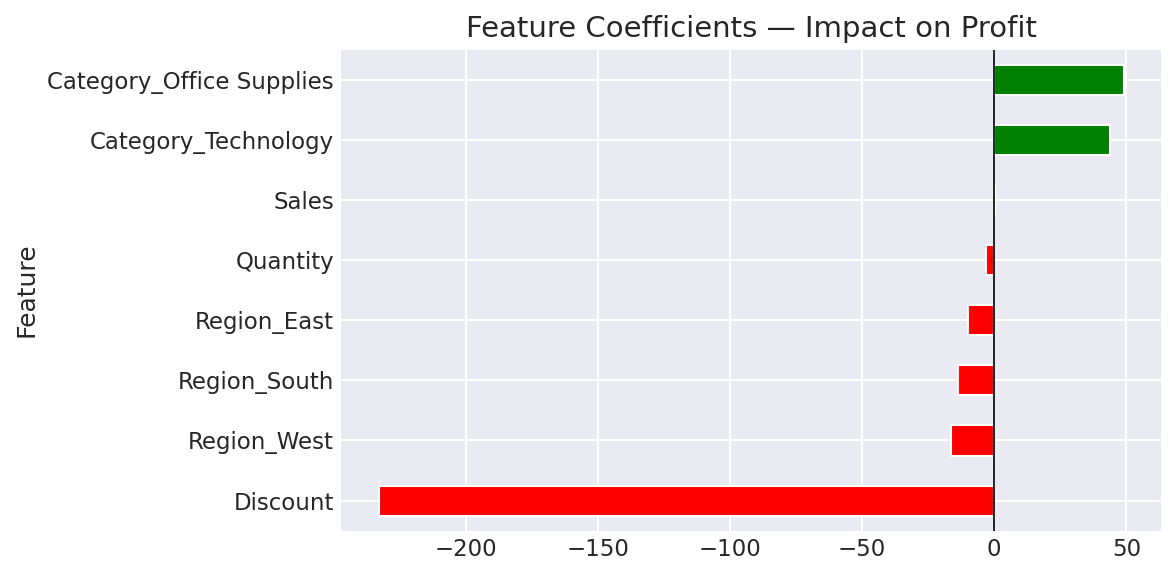

In [28]:
# Visualize model coefficients
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
             color=colors, legend=False, figsize=(8, 4))
plt.title('Feature Coefficients — Impact on Profit')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Business Interpretation

In [29]:
print("=== BUSINESS INTERPRETATION ===")
print(f"""
Model Performance:
  - R² Score: {r2:.4f} — the model explains {r2*100:.1f}% of profit variance
  - MAE: ${mae:.2f} — average prediction error per transaction

Key Drivers of Profit (from coefficients):
  - Discount has the strongest NEGATIVE impact (-$231 per unit increase)
  - Sales has a positive but modest impact (+$0.18 per dollar sold)
  - Quantity alone does not guarantee profit (-$3.07 per unit)

Business Recommendation:
  - Orders with high discounts are strongly associated with losses in these sub-categories
  - If this association holds when discount is reduced, profit could rise from
    $50,450 to $84,233 (+67%) - recommended to validate with a controlled experiment
    (A/B test) before changing discount policy, since discounts may have been
    assigned precisely to the lowest-margin products in the first place (confounding variable)
  - Priority action: Review discount policy for Tables (-$17,725 total loss)
""")

=== BUSINESS INTERPRETATION ===

Model Performance:
  - R² Score: 0.1798 — the model explains 18.0% of profit variance
  - MAE: $59.45 — average prediction error per transaction

Key Drivers of Profit (from coefficients):
  - Discount has the strongest NEGATIVE impact (-$231 per unit increase)
  - Sales has a positive but modest impact (+$0.18 per dollar sold)
  - Quantity alone does not guarantee profit (-$3.07 per unit)

Business Recommendation:
  - Orders with high discounts are strongly associated with losses in these sub-categories
  - If this association holds when discount is reduced, profit could rise from
    $50,450 to $84,233 (+67%) - recommended to validate with a controlled experiment
    (A/B test) before changing discount policy, since discounts may have been
    assigned precisely to the lowest-margin products in the first place (confounding variable)
  - Priority action: Review discount policy for Tables (-$17,725 total loss)



### Conclusions
- High discounts negatively affect profitability Discount is the strongest negative driver of Profit in the regression ($-231 per unit increase).
- Sales positively influence Profit, while Quantity alone does not guarantee profit.
- Tables, Bookcases, and Supplies are the least profitable sub-categories, and clustering confirms this pattern: Cluster 3 (874 heavily-discounted transactions, avg. 71% discount) loses money on average.
- Bulk-quantity orders (Cluster 2, 1,637 transactions, ~7.6 items per order) are just as profitable as mid-size orders — volume alone doesn't hurt margin when discounts stay moderate.
- Reducing or eliminating discounts on the losing sub-categories could raise their combined profit from $50,450 to $84,233 (+67%), per the simulation above — a correlational estimate that should be validated with a controlled experiment before changing discount policy.